In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

df_inj = pd.read_csv(r"..\Uncleaned dataset\Injuries_By_Person_Type_Raw.csv")
df_death = pd.read_csv(r"..\Uncleaned dataset\Fatalities_By_Person_Type_Raw.csv")

print(df_death.head())
print(df_death.info())
print(df_death.describe())

   Year  District  Driver_Killed  Passenger_Killed  Pedestrian_Killed  Total
0  2015   Central             67                23                 61    151
1  2015   Eastern             25                14                 23     62
2  2015  Northern             48                11                 33     92
3  2015  Southern             65                14                 66    145
4  2015   Western             27                 7                 52     86
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60 entries, 0 to 59
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Year               60 non-null     int64 
 1   District           60 non-null     object
 2   Driver_Killed      60 non-null     int64 
 3   Passenger_Killed   60 non-null     int64 
 4   Pedestrian_Killed  60 non-null     int64 
 5   Total              60 non-null     int64 
dtypes: int64(5), object(1)
memory usage: 2.9+ KB
None
     

In [2]:
print(df_inj.head())
print(df_inj.info())
print(df_inj.describe())

   Year  District  Driver_Injured  Passenger_Injured  Pedestrian_Injured  \
0  2015   Central            2756               1957                1257   
1  2015   Eastern            2024               1150                 818   
2  2015  Northern            1382                827                 981   
3  2015  Southern            3469               1739                1953   
4  2015   Western             710                339                 496   

   Total  
0   5970  
1   3992  
2   3190  
3   7161  
4   1545  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60 entries, 0 to 59
Data columns (total 6 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Year                60 non-null     int64 
 1   District            60 non-null     object
 2   Driver_Injured      60 non-null     int64 
 3   Passenger_Injured   60 non-null     int64 
 4   Pedestrian_Injured  60 non-null     int64 
 5   Total               60 non-null   

In [3]:
def unique(dataset):
    print(dataset.nunique())
    print(dataset.unique())
    print(dataset.value_counts())

unique(df_inj['Year'])
unique(df_inj['District'])
unique(df_death['Year'])
unique(df_death['District'])

10
[2015 2016 2017 2018 2019 2020 2021 2022 2023 2024]
Year
2015    6
2016    6
2017    6
2018    6
2019    6
2020    6
2021    6
2022    6
2023    6
2024    6
Name: count, dtype: int64
6
['Central' 'Eastern' 'Northern' 'Southern' 'Western' 'Grand Total']
District
Central        10
Eastern        10
Northern       10
Southern       10
Western        10
Grand Total    10
Name: count, dtype: int64
10
[2015 2016 2017 2018 2019 2020 2021 2022 2023 2024]
Year
2015    6
2016    6
2017    6
2018    6
2019    6
2020    6
2021    6
2022    6
2023    6
2024    6
Name: count, dtype: int64
6
['Central' 'Eastern' 'Northern' 'Southern' 'Western' 'Grand Total']
District
Central        10
Eastern        10
Northern       10
Southern       10
Western        10
Grand Total    10
Name: count, dtype: int64


merged_df = pd.merge(
    left = df_death,
    right = df_inj,
    on = ['Year', District'],
    how ='left'
)

print(merged_df.head())

In [5]:
merged_df = pd.merge(
    left = df_death,
    right = df_inj,
    on = ['Year', 'District'],
    how = 'left'
)

merged_df = merged_df.drop(columns = ['Total_x','Total_y'])
print(merged_df.head())

   Year  District  Driver_Killed  Passenger_Killed  Pedestrian_Killed  \
0  2015   Central             67                23                 61   
1  2015   Eastern             25                14                 23   
2  2015  Northern             48                11                 33   
3  2015  Southern             65                14                 66   
4  2015   Western             27                 7                 52   

   Driver_Injured  Passenger_Injured  Pedestrian_Injured  
0            2756               1957                1257  
1            2024               1150                 818  
2            1382                827                 981  
3            3469               1739                1953  
4             710                339                 496  


In [6]:
unique(merged_df['District'])
merged_df = merged_df[merged_df['District'] != 'Grand Total']

6
['Central' 'Eastern' 'Northern' 'Southern' 'Western' 'Grand Total']
District
Central        10
Eastern        10
Northern       10
Southern       10
Western        10
Grand Total    10
Name: count, dtype: int64


In [7]:
merged_df.info()
unique(merged_df['District'])

<class 'pandas.core.frame.DataFrame'>
Index: 50 entries, 0 to 58
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Year                50 non-null     int64 
 1   District            50 non-null     object
 2   Driver_Killed       50 non-null     int64 
 3   Passenger_Killed    50 non-null     int64 
 4   Pedestrian_Killed   50 non-null     int64 
 5   Driver_Injured      50 non-null     int64 
 6   Passenger_Injured   50 non-null     int64 
 7   Pedestrian_Injured  50 non-null     int64 
dtypes: int64(7), object(1)
memory usage: 3.5+ KB
5
['Central' 'Eastern' 'Northern' 'Southern' 'Western']
District
Central     10
Eastern     10
Northern    10
Southern    10
Western     10
Name: count, dtype: int64


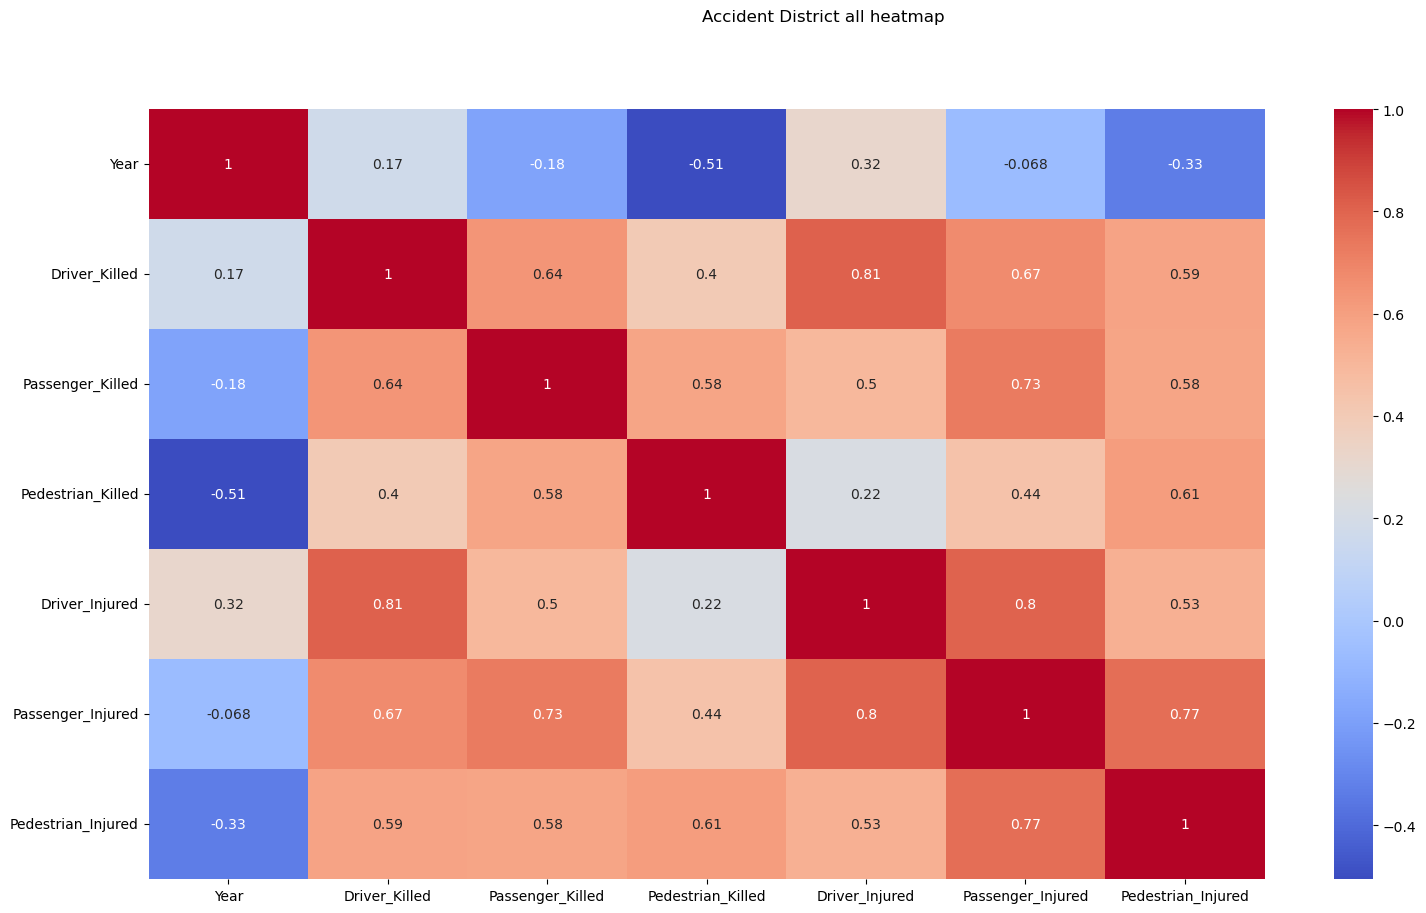

In [8]:
plt.figure(figsize=(18, 10))
sns.heatmap(merged_df[['Year', 'Driver_Killed', 'Passenger_Killed',
       'Pedestrian_Killed', 'Driver_Injured', 'Passenger_Injured',
       'Pedestrian_Injured']].corr(),
           annot=True,
           cmap='coolwarm')
plt.suptitle('Accident District all heatmap')
plt.savefig('Accident District all heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

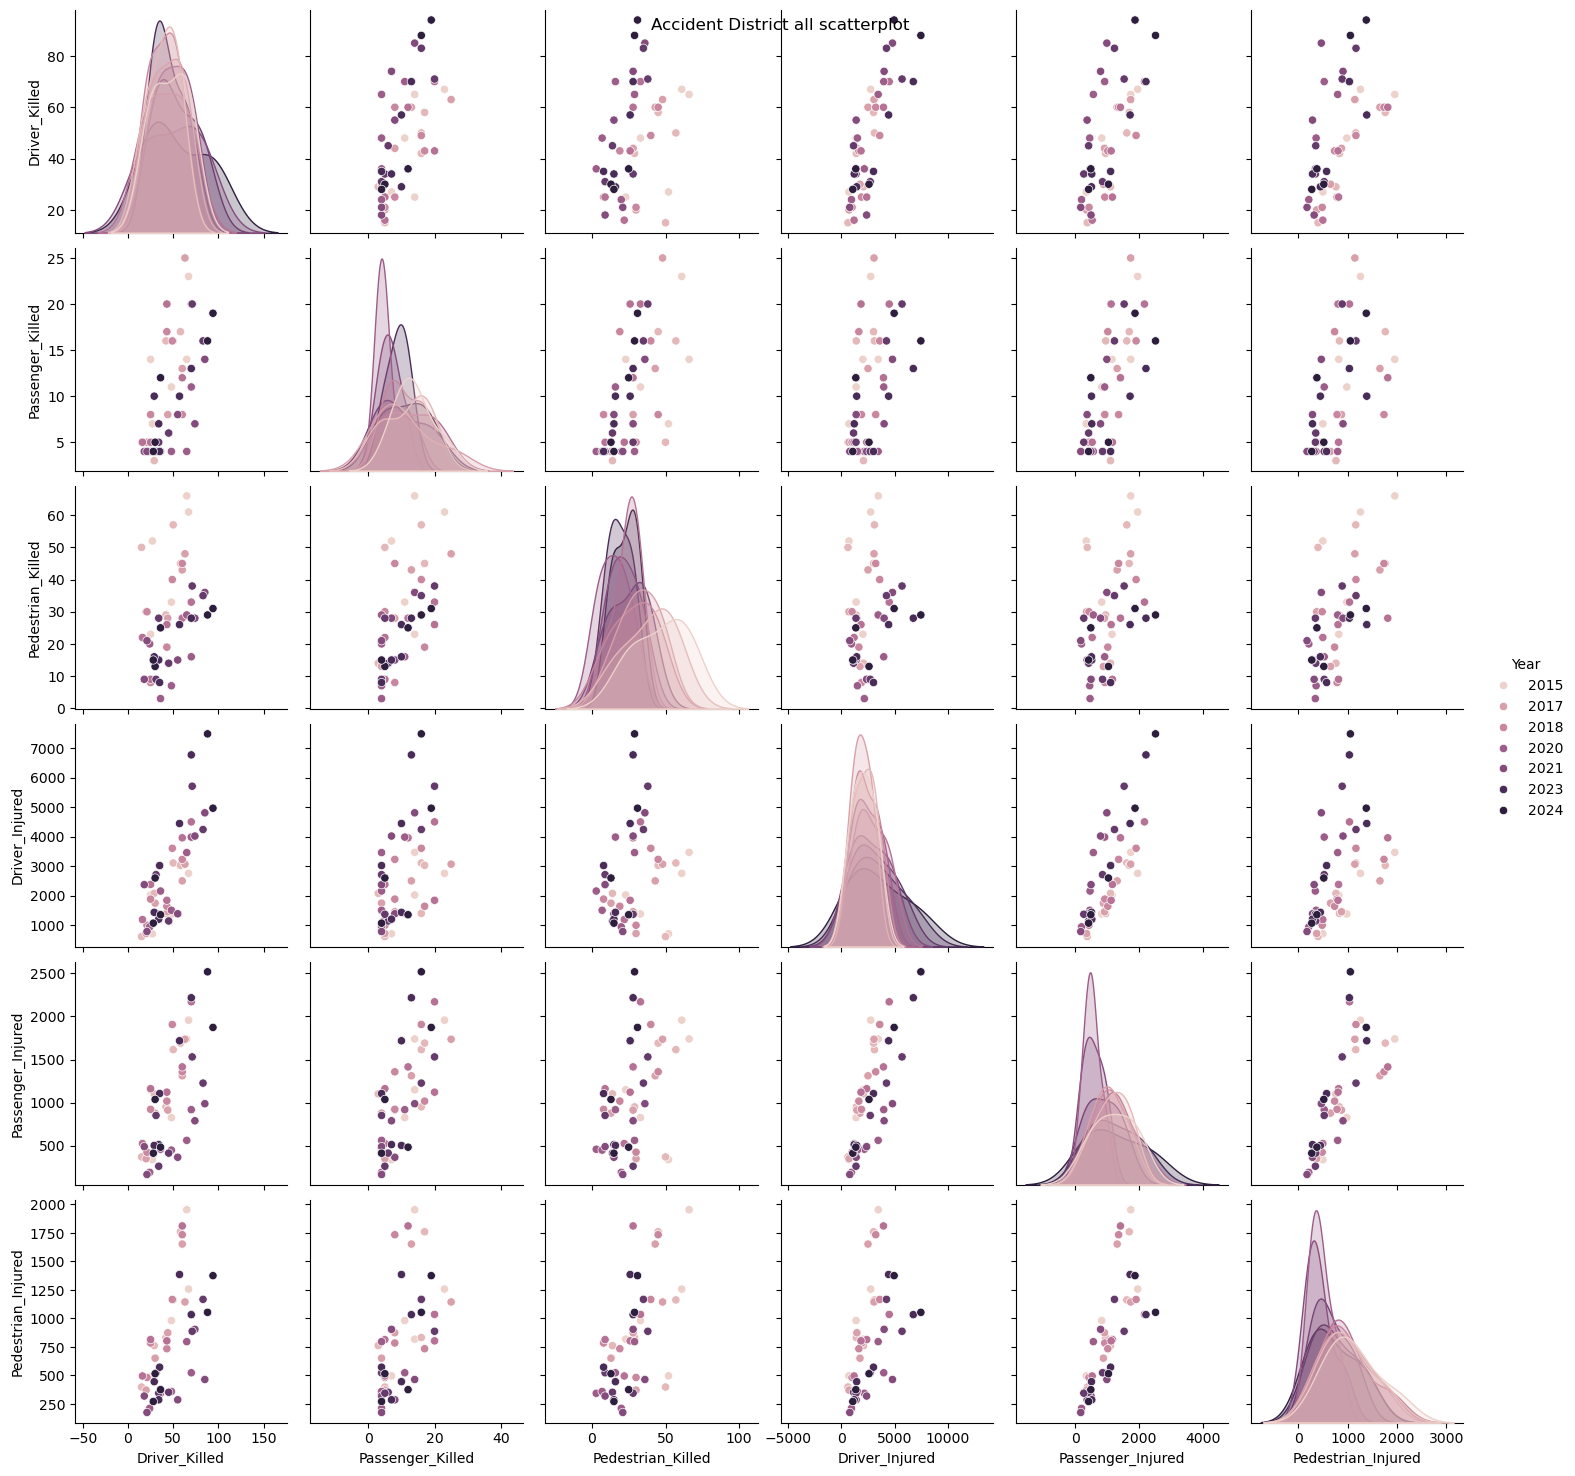

In [9]:
sns.pairplot(merged_df[['Driver_Killed', 'Passenger_Killed',
       'Pedestrian_Killed', 'Driver_Injured', 'Passenger_Injured',
       'Pedestrian_Injured']+ ['Year']], 
            diag_kind = 'kde',
            hue= 'Year')
plt.suptitle('Accident District all scatterplot')
plt.savefig('Accident District all scatterplot.png', dpi=300, bbox_inches='tight')
plt.show()

array([[<Axes: title={'center': 'Year'}>,
        <Axes: title={'center': 'Driver_Killed'}>,
        <Axes: title={'center': 'Passenger_Killed'}>],
       [<Axes: title={'center': 'Pedestrian_Killed'}>,
        <Axes: title={'center': 'Driver_Injured'}>,
        <Axes: title={'center': 'Passenger_Injured'}>],
       [<Axes: title={'center': 'Pedestrian_Injured'}>, <Axes: >,
        <Axes: >]], dtype=object)

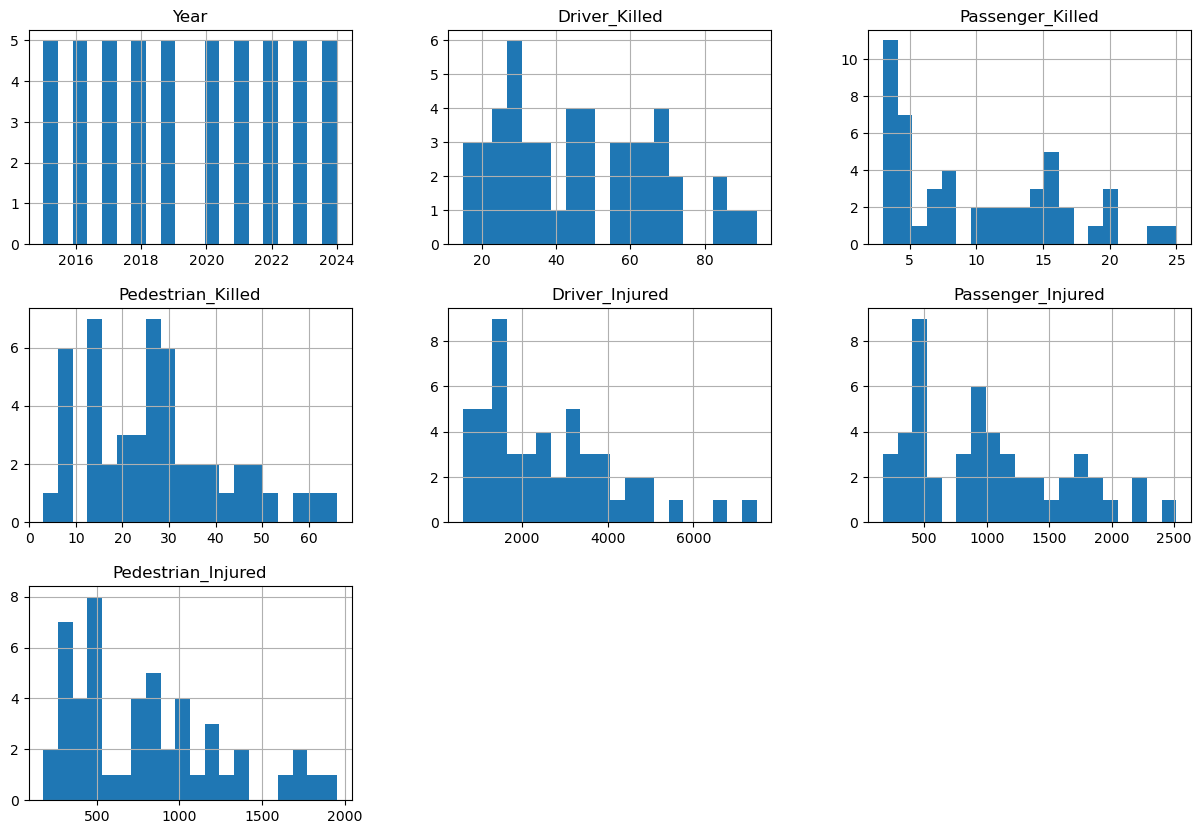

In [10]:
merged_df.hist(figsize=(15, 10), bins=20)

In [11]:
def skew_check(dataset,val):
    print("Skewness Check:")
    for col in val:
        skew = dataset[col].skew()
        print(f"{col:10s}: {skew:6.2f} {'TRANSFORM' if abs(skew) > 1 else 'OK'}")

skew_check(merged_df,['Driver_Killed', 'Passenger_Killed',
       'Pedestrian_Killed', 'Driver_Injured', 'Passenger_Injured',
       'Pedestrian_Injured'])

Skewness Check:
Driver_Killed:   0.43 OK
Passenger_Killed:   0.64 OK
Pedestrian_Killed:   0.65 OK
Driver_Injured:   1.09 TRANSFORM
Passenger_Injured:   0.59 OK
Pedestrian_Injured:   0.83 OK


In [20]:
merged_df_ML = merged_df
merged_df_ML['Driver_Injured_sqrt'] = np.sqrt(merged_df['Driver_Injured'])
skew_check(merged_df,['Driver_Killed', 'Passenger_Killed',
       'Pedestrian_Killed', 'Driver_Injured_sqrt', 'Passenger_Injured',
       'Pedestrian_Injured'])

Skewness Check:
Driver_Killed:   0.43 OK
Passenger_Killed:   0.64 OK
Pedestrian_Killed:   0.65 OK
Driver_Injured_sqrt:   0.49 OK
Passenger_Injured:   0.59 OK
Pedestrian_Injured:   0.83 OK


array([[<Axes: title={'center': 'Year'}>,
        <Axes: title={'center': 'Driver_Killed'}>,
        <Axes: title={'center': 'Passenger_Killed'}>],
       [<Axes: title={'center': 'Pedestrian_Killed'}>,
        <Axes: title={'center': 'Driver_Injured'}>,
        <Axes: title={'center': 'Passenger_Injured'}>],
       [<Axes: title={'center': 'Pedestrian_Injured'}>,
        <Axes: title={'center': 'Driver_Injured_sqrt'}>, <Axes: >]],
      dtype=object)

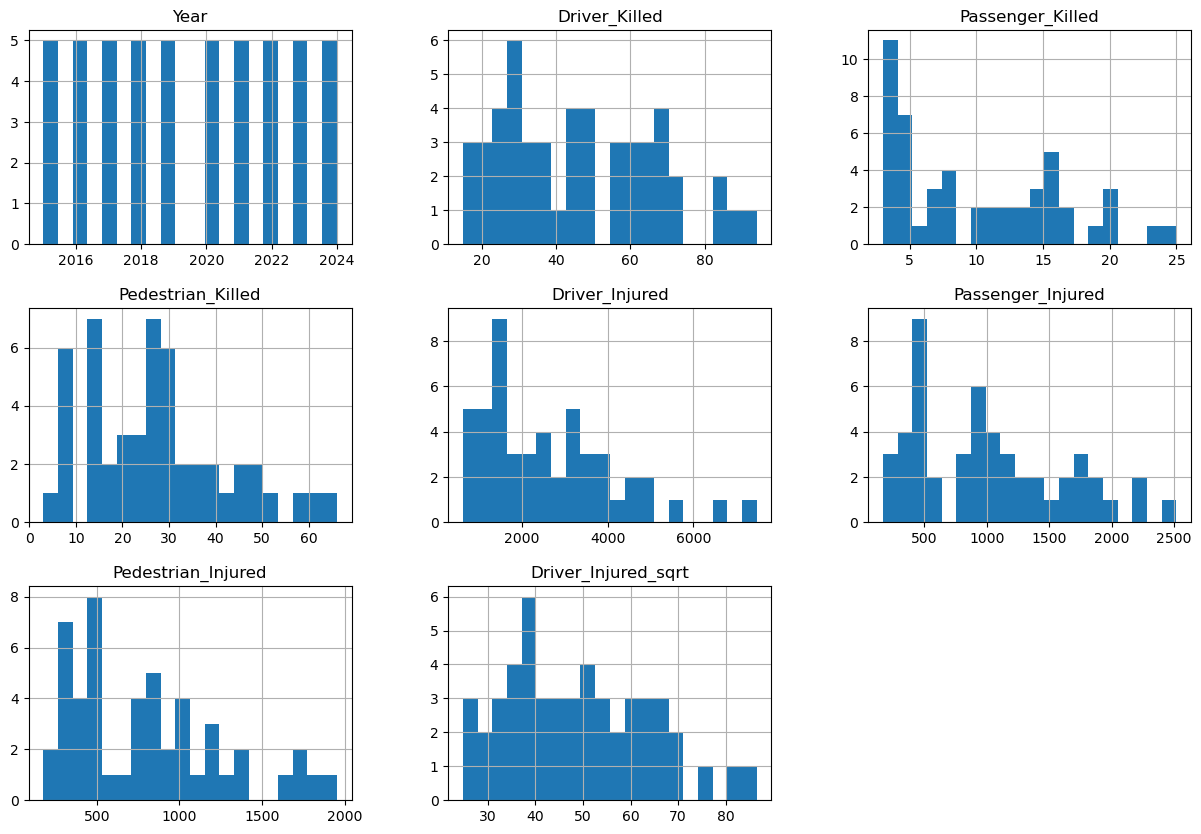

In [22]:
merged_df_ML.hist(figsize=(15, 10), bins=20)

In [24]:
merged_df.to_csv('Accident District.csv', index=False)
merged_df_ML.to_csv('Accident District_ML.csv', index=False)